# Multilingual Characterization and Extraction of Narratives from Online News
## Subtask 2: Narrative Classification with DistilBERT
---
**Author:** Manuel Carlucci  
**Student ID:** 855237  
**Email:** m.carlucci69@studenti.uniba.it



### Task Definition
Given a news article and a two-level taxonomy of narrative labels, assign all appropriate **sub-narrative labels**.
Dominant narratives are **derived automatically** from sub-narrative predictions via the hierarchy mapping.

**Model:** `distilbert-base-uncased`  
**Loss:** `BCEWithLogitsLoss` with per-label `pos_weight` (handles class imbalance)  
**Evaluation:** Micro-F1 @ fine (sub-narrative) + Micro-F1 @ coarse (dominant narrative)

### Key fixes over naive BERT baseline
- `MAX_LEN=dynamic` (ceil(mean token length × 1.20), max 512)
- `warmup_ratio=0.03`:3% warmup
- `WeightedTrainer` with data-driven `pos_weight`: fixes frozen F1 caused by extreme label sparsity (~2% positive rate)


## Setup and Installation


In [ ]:
# Uninstall torchvision to avoid VideoReader import conflict with datasets
!pip uninstall torchvision -y -q

In [ ]:
!pip install -q transformers datasets scikit-learn accelerate


In [ ]:
import sys

# Remove torchvision from the live session before datasets loads.
# datasets.formatting.torch_formatter tries to import torchvision.io.VideoReader
# which is missing in the Colab-preinstalled torchvision build: this causes
# an ImportError at trainer.train() time. Evicting the module here prevents
# datasets from ever entering that code path.
for _mod in list(sys.modules.keys()):
    if "torchvision" in _mod:
        del sys.modules[_mod]

import os, json
import pickle   # for model saving
import re       # regular expression
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset    # Converts data into Hugging Face dataset format.

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import f1_score

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# to move computation into GPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


Using device: cuda


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

BASE              = "/content/drive/MyDrive/NLP_Project"
NARRATIVES        = f"{BASE}/subtask_2/subtask2_narratives.txt"
SUBNARRATIVES     = f"{BASE}/subtask_2/subtask2_subnarratives.txt"
TRAIN_DOCS_DIR    = f"{BASE}/training/EN/raw-documents"
TRAIN_ANNOTATIONS = f"{BASE}/subtask_2/training/EN/subtask-2-annotations.txt"
TEST_DOCS_DIR     = f"{BASE}/subtask_2/test/EN/subtask-2-documents"
GOLD_FILE         = f"{BASE}/subtask_2/test/EN/subtask-2-annotations.txt"
OUTPUT_FILE       = f"{BASE}/predictions_subtask2_EN_bert.txt"
SAVE_DIR          = f"{BASE}/bert_subtask2_final"
LANG              = "EN"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Label Taxonomy

Labels are loaded from the plain-text files on Drive (one label per line),
reusing the same helper from the Gensim pipeline.


In [ ]:
def load_label_list(path):
    """Read a plain-text label file (one label per line)."""
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]


narrative_labels    = load_label_list(NARRATIVES)
subnarrative_labels = load_label_list(SUBNARRATIVES)

print(f"Dominant narrative labels : {len(narrative_labels)}")
print(f"Sub-narrative labels      : {len(subnarrative_labels)}")


Dominant narrative labels : 22
Sub-narrative labels      : 91


## Load and Parse Data

Same `parse_annotations` and `load_texts` helpers from the Gensim pipeline.


In [ ]:
def parse_annotations(annotation_file):
    """Parse TSV annotation file into a DataFrame."""
    records = []
    with open(annotation_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            article_id = parts[0].strip()
            lang = article_id.split("_")[0] if "_" in article_id else "UNK"
            dom_str = parts[1].strip() if len(parts) > 1 else "Other"
            sub_str = parts[2].strip() if len(parts) > 2 else dom_str
            dom_labels = list(dict.fromkeys(l.strip() for l in dom_str.split(";") if l.strip()))  # dict.fromkeys() removes duplicates while preserving order:
            sub_labels = list(dict.fromkeys(l.strip() for l in sub_str.split(";") if l.strip()))
            records.append({
                "article_id"    : article_id,
                "language"      : lang,
                "dom_narratives": dom_labels,
                "subnarratives" : sub_labels,
            })
    return pd.DataFrame(records)


def load_texts(docs_dir, article_ids):
    """Read raw text files; return {article_id: text}."""
    texts = {}
    for aid in article_ids:
        for fname in [f"{aid}.txt", str(aid)]:
            fpath = os.path.join(docs_dir, fname)
            if os.path.exists(fpath):
                with open(fpath, "r", encoding="utf-8", errors="replace") as f:
                    texts[aid] = f.read()
                break
        else:
            texts[aid] = ""
    return texts


df_raw = parse_annotations(TRAIN_ANNOTATIONS)
df_raw = df_raw[df_raw["language"] == LANG].reset_index(drop=True)    # reset index after removing all data about different languages
print(f"EN training instances: {len(df_raw)}")

texts = load_texts(TRAIN_DOCS_DIR, df_raw["article_id"].tolist())
df_raw["text"] = df_raw["article_id"].map(texts)                      # add text field to each element
print(f"Texts loaded: {df_raw['text'].str.len().gt(0).sum()} / {len(df_raw)}")    # gt = greater than 0 and sum booleans
df_raw.head(3)


EN training instances: 399
Texts loaded: 399 / 399


,article_id,language,dom_narratives,subnarratives,text
0,EN_CC_100013.txt,EN,[CC: Criticism of climate movement],[CC: Criticism of climate movement: Ad hominem...,Bill Gates Says He Is ‘The Solution’ To Climat...
1,EN_UA_300009.txt,EN,[Other],[Other],Russia: Clashes erupt in Bashkortostan as righ...
2,EN_UA_300017.txt,EN,[Other],[Other],"McDonald's to exit Russia, sell business in co..."


## Multi-label binarization and hierarchical label mapping

The narrative annotations are first converted into binary multi-label matrices using MultiLabelBinarizer. Separate encodings are created for sub-narratives (fine level) and dominant narratives (coarse level)

The label "Other" is temporarily excluded from the binarization process because it represents a special catch-all category rather than a semantic narrative class.

A hierarchical mapping between sub-narratives and dominant narratives is then constructed. Since sub-narratives are organized under higher-level narrative groups (e.g. URW: ... or CC: ...), each fine-grained prediction can later be automatically mapped back to its corresponding dominant category.

The function *fine_pred_to_coarse* implements this conversion by aggregating sub-narrative predictions into dominant narrative predictions through logical OR pooling.

Finally, statistics about the label space and the number of "Other"-only instances are printed to verify the structure and dimensionality of the dataset.

In [ ]:
def without_other(label_list):
    return [l for l in label_list if l != "Other"]


# Sub-narrative (fine) binarisation
all_sub_labels = sorted(set(
    l for labels in df_raw["subnarratives"].apply(without_other) for l in labels    # flatten everything, remove duplicates (set) and sort
))
sub_mlb = MultiLabelBinarizer(classes=all_sub_labels)
sub_mlb.fit([all_sub_labels])
Y_sub = sub_mlb.transform(df_raw["subnarratives"].apply(without_other))

# Dominant narrative (coarse) binarisation
all_dom_labels = sorted(set(
    l for labels in df_raw["dom_narratives"].apply(without_other) for l in labels
))
dom_mlb = MultiLabelBinarizer(classes=all_dom_labels)
dom_mlb.fit([all_dom_labels])
Y_dom = dom_mlb.transform(df_raw["dom_narratives"].apply(without_other))

# Hierarchy mapping: sub-narrative -> dominant narrative
# URW: Overpraising the West  ---> URW
def sub_to_dom(sub_label: str):
    for dom in all_dom_labels:
        if sub_label == dom or sub_label.startswith(dom + ":"):
            return dom
    return None

sub2dom = {s: sub_to_dom(s) for s in all_sub_labels}


def fine_pred_to_coarse(Y_sub_pred: np.ndarray) -> np.ndarray:
    """Convert binary sub-narrative matrix -> dominant-narrative matrix via OR pooling."""
    # Creates an empty dominant matrix:
    Y_dom_pred = np.zeros((Y_sub_pred.shape[0], len(all_dom_labels)), dtype=int)
    # loop over sub labels and find the dominant narrative
    for sub_idx, sub_lbl in enumerate(sub_mlb.classes_):
        dom_lbl = sub2dom.get(sub_lbl)
        if dom_lbl and dom_lbl in dom_mlb.classes_:
            dom_idx = list(dom_mlb.classes_).index(dom_lbl)
            # If ANY child sub-narrative is predicted, the parent dominant narrative becomes positive.
            # ex. Politics:War = 1;  Politics:Propaganda = 1  --> Politics
            Y_dom_pred[:, dom_idx] |= Y_sub_pred[:, sub_idx]
    return Y_dom_pred

# If the only label is 'other' (not cases like ["Health", "Other"])
is_other = df_raw["dom_narratives"].apply(lambda ls: ls == ["Other"]).astype(int)

print(f"Sub-narrative classes : {len(all_sub_labels)}")
print(f"Dominant classes      : {len(all_dom_labels)}")
print(f"Y_sub shape           : {Y_sub.shape}")
print(f"Other-only instances  : {is_other.sum()}")


Sub-narrative classes : 83
Dominant classes      : 21
Y_sub shape           : (399, 83)
Other-only instances  : 169


## Computing class weights to address label imbalance

This section estimates the degree of imbalance for each sub-narrative label and computes a corresponding pos_weight value for weighted multi-label training.

Because the dataset is **highly imbalanced**, many narrative labels appear only a small number of times, while others are much more frequent. Without correction, the model would tend to focus primarily on frequent labels and largely ignore rare ones.

To mitigate this issue we compute the the number of positive and negative examples for each label and a per-label weight is derived as:

$\text{pos_weight}_j = \frac{\text{negative examples}_j}{\text{positive examples}_j}$


This weighting strategy increases the penalty associated with misclassifying rare labels during training.

A safeguard is included to avoid division-by-zero errors for labels that may have no positive examples in the training set.

Finally, a visualization of the sorted pos_weight values is generated to inspect how strongly the dataset distribution varies across labels. Large weight values indicate extremely rare labels that may be difficult for the model to learn effectively.


Mean pos_weight : 106.2
Min  pos_weight : 11.1
Max  pos_weight : 398.0
Mean positive rate per label: 0.0213


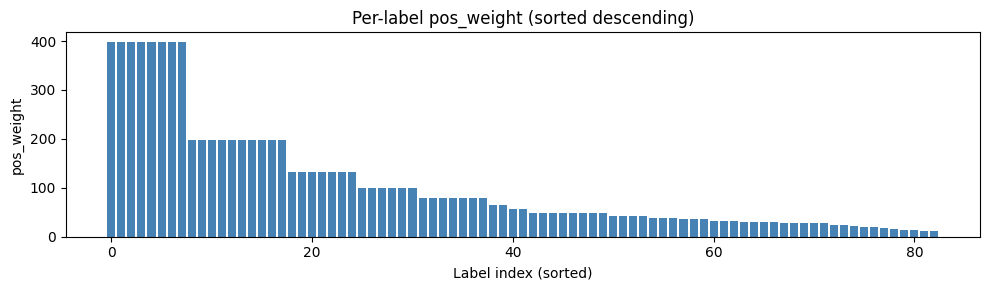

In [ ]:
# Compute per-label positive/negative counts
pos_counts = Y_sub.sum(axis=0).astype(float)                # sum by row
neg_counts  = (Y_sub.shape[0] - pos_counts).astype(float)   # negatives = N - positives

# Avoid division by zero for labels with no positives in training set, replacing 0 by 1
pos_counts_safe = np.where(pos_counts == 0, 1.0, pos_counts)
pos_weight_values = torch.tensor(
    neg_counts / pos_counts_safe, dtype=torch.float32
)

print(f"Mean pos_weight : {pos_weight_values.mean():.1f}")
print(f"Min  pos_weight : {pos_weight_values.min():.1f}")
print(f"Max  pos_weight : {pos_weight_values.max():.1f}")
print(f"Mean positive rate per label: {(pos_counts / Y_sub.shape[0]).mean():.4f}")

# Visual check
plt.figure(figsize=(10, 3))
plt.bar(range(len(pos_weight_values)), sorted(pos_weight_values.numpy(), reverse=True),
        color="steelblue", edgecolor="none")
plt.title("Per-label pos_weight (sorted descending)")
plt.xlabel("Label index (sorted)")
plt.ylabel("pos_weight")
plt.tight_layout()
plt.show()


## Tokenization
This section initializes the Transformer configuration used for multi-label narrative classification with DistilBERT.
`MAX_LEN=dynamic`: computed as `ceil(mean_token_length × 1.20)`, capped at 512. This ensures the window covers the average article length with a 20% margin, avoiding both unnecessary truncation and wasted compute.

`BATCH_SIZE=16`: larger batches give more stable gradient estimates on a small dataset.

`TOKENIZER=bert-base-uncased`: the canonical BERT tokenizer, correct pairing for the DistilBERT architecture.

After the initial configuration we define a function with aim to convert raw text data and multi-label annotations into a format compatible with Transformer training using DistilBERT.

Each document is paired with its corresponding binary label vector, where each position indicates the presence (1.0) or absence (0.0) of a sub-narrative label. Labels are explicitly converted to float values because the training objective (BCEWithLogitsLoss) requires continuous inputs.

The text is then tokenized using the pretrained tokenizer with truncation to handle long documents, padding to ensure uniform sequence length (MAX_LEN) and
conversion into input IDs and attention masks

The function removes unused text columns and formats the dataset as PyTorch tensors to ensure compatibility with the Hugging Face Trainer.

Finally, the full training dataset is created from all available articles, producing a structured dataset ready for multi-label fine-tuning.


In [ ]:
MOL_NAME = "distilbert-base-uncased"

# Use the BERT tokezer (bert-base-uncased): same WordPiece vocabulary as DistilBERT,
# but the canonical BERT tokenizer is the correct pairing for bert-base-uncased weights.
TOKENIZER_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

#  Dynic MAX_LEN: compute mean token length on training texts, then add 20% margin
impormath
_sample_texts = df_raw["text"].fillna("").tolist()
# For each text t, the tokenizer converts it into tokens
_token_lens   = [
    len(tokenizer.encode(t, add_special_tokens=True, truncation=False))
    for t in _sample_texts
]
_mean_len = sum(_token_lens) / len(_token_lens)
MAX_LEN   = min(512, math.ceil(_mean_len * 1.20))   # +20% margin, hard cap at 512

print(f"Tokenizer : {TOKENIZER_NAME}")
print(f"Mean token length : {_mean_len:.1f}")
print(f"MAX_LEN set to    : {MAX_LEN}  (ceil(mean)*1.20, capped at 512)")

NUM_LABELS = len(all_sub_labels)
print(f"NUM_LABELS: {NUM_LABELS}")


Token indices sequence length is longer than the specified maximum sequence length for this model (543 > 512). Running this sequence through the model will result in indexing errors


Tokenizer : bert-base-uncased
Mean token length : 616.7
MAX_LEN set to    : 512  (ceil(mean)*1.20, capped at 512)
NUM_LABELS: 83


In [ ]:
def build_hf_dataset(texts_list, y_matrix):
    """
    Build a HuggingFace Dataset from texts + binary label matrix.
    Labels are float (required by BCEWithLogitsLoss).
    """
    # texts_list = ["text 1", "text 2", ...], y_matrix = [[1,0, ...], [0,1, ...]]
    df_tmp = pd.DataFrame({
        "text"  : texts_list,
        "labels": list(y_matrix.astype(float)),
    })
    ds = Dataset.from_pandas(df_tmp)

    def tokenize_fn(examples):
        enc = tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
        )
        enc["labels"] = [list(map(float, lbl)) for lbl in examples["labels"]] # trasnforms into float labels (1.0, ...)
        return enc

    ds = ds.map(tokenize_fn, batched=True)
    ds = ds.remove_columns(["text"])
    if "__index_level_0__" in ds.column_names:
        ds = ds.remove_columns(["__index_level_0__"])
    ds.set_format("torch")
    return ds


train_texts   = df_raw["text"].fillna("").tolist()
train_ds_full = build_hf_dataset(train_texts, Y_sub)
print(f"Full training dataset: {len(train_ds_full)} samples")


Map:   0%|          | 0/399 [00:00<?, ? examples/s]

Full training dataset: 399 samples


## WeightedTrainer: Fix for Frozen F1

The default `Trainer` uses `BCEWithLogitsLoss` with equal weight for all labels.
With about 2% positive rate the model learns to predict all zeros (frozen F1 at 0.038).

`WeightedTrainer` overrides `compute_loss` to pass the data-driven `pos_weight` tensor,
forcing the model to treat each positive example as much more important than a negative one.


In [ ]:
# Normally Trainer handles training automatically and uses default loss internally. But here you override the compute_loss() called at every training step
class WeightedTrainer(Trainer):
    """
    Custom Trainer that uses per-label pos_weight in BCEWithLogitsLoss.
    Fixes the frozen-F1 problem caused by extreme label sparsity.
    """
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")    # Il modello BERT non vuole ricevere le labels dentro forward() quando stai usando loss custom.
        outputs = model(**inputs)
        logits  = outputs.logits          # logits = raw predictions (e.g. [2.3, -1.2, 0.7])
        loss_fn = torch.nn.BCEWithLogitsLoss(
            pos_weight=pos_weight_values.to(logits.device)    # we move to same device (GPU). Used to give penalities - rare labels matter more
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss    # return loss is for training, output is for debugging


## Evaluation Helpers & Threshold Tuning

Same helpers as the Gensim pipeline.
- `compute_metrics_multilabel`: epoch-level monitoring inside Trainer
- `tune_thresholds` / `apply_thresholds`: per-label threshold optimisation (tuned on training data)
- `evaluate`: prints F1@fine + F1@coarse


In [ ]:
def compute_metrics_multilabel(pred):
    """Metric function for HuggingFace Trainer: monitors F1 during training."""
    labels = pred.label_ids
    logits = pred.predictions
    probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    preds  = (probs > 0.5).astype(int)

    f1_micro  = f1_score(labels, preds, average="micro",  zero_division=0)
    f1_macro  = f1_score(labels, preds, average="macro",  zero_division=0)
    pred_dom  = fine_pred_to_coarse(preds)
    true_dom  = fine_pred_to_coarse(labels.astype(int))
    f1_coarse = f1_score(true_dom, pred_dom, average="micro", zero_division=0)
    return {"f1_micro": f1_micro, "f1_macro": f1_macro, "f1_coarse": f1_coarse}


def evaluate(y_true_sub, y_pred_sub, y_true_dom, y_pred_dom, label=""):
    """Print and return F1@fine + F1@coarse."""
    f1_fine   = f1_score(y_true_sub, y_pred_sub, average="micro", zero_division=0)
    f1_coarse = f1_score(y_true_dom, y_pred_dom, average="micro", zero_division=0)
    if label:
        print(f"[{label}]  F1@fine={f1_fine:.4f}   F1@coarse={f1_coarse:.4f}")
    return f1_fine, f1_coarse


def tune_thresholds(y_true: np.ndarray, probs: np.ndarray,
                    candidates=None) -> np.ndarray:
    """Per-label threshold search maximising label-level F1 on training data."""
    if candidates is None:
        candidates = np.arange(0.1, 0.91, 0.05)
    n_labels    = y_true.shape[1]
    best_thresh = np.full(n_labels, 0.5)
    for j in range(n_labels):
        best_f1, best_t = -1.0, 0.5
        for t in candidates:
            preds_j = (probs[:, j] >= t).astype(int)
            f = f1_score(y_true[:, j], preds_j, zero_division=0)
            if f > best_f1:
                best_f1, best_t = f, t
        best_thresh[j] = best_t
    return best_thresh


def apply_thresholds(probs: np.ndarray, thresholds: np.ndarray) -> np.ndarray:
    return (probs >= thresholds).astype(int)


def get_probs(trainer, dataset):
    """Run Trainer.predict and apply sigmoid to get probabilities."""
    out = trainer.predict(dataset)    # it returns row preditions (e.g. [1.2, -2.3])
    return torch.sigmoid(torch.tensor(out.predictions)).numpy() # we apply sigmoid to obtain prob value. The result converted in numpy format for the evauation metrics


## Model & Hyperparameters

Key changes from the naive baseline:
- `EPOCHS=10`: more epochs needed for small dataset
- `BATCH_SIZE=16`: larger batch for stable gradients
- `lr=3e-5`: slightly higher than default for faster convergence
- `warmup_ratio=0.03`: 3% warmup (~6 steps out of ~200 total), calibrated for ~399 samples
- `WeightedTrainer`: replaces Trainer everywhere


In [ ]:
import math

EPOCHS     = 10
BATCH_SIZE = 16
LR         = 3e-5


def load_bert_model():
    """Load a fresh DistilBERT model for multi-label sequence classification.
    problem_type is set to multi_label_classification so HuggingFace knows
    the architecture; actual loss is overridden by WeightedTrainer.
    """
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        problem_type="multi_label_classification",
    )


# Compute warmup_steps explicitly
# Formula: total_steps = ceil(n_train / batch_size) * epochs
# warmup_steps = round(total_steps * 0.03) : 3% warmup
WARMUP_RATIO   = 0.03
_n_train       = len(df_raw)                          # full training set size
_steps_per_epoch = math.ceil(_n_train / BATCH_SIZE)
_total_steps     = _steps_per_epoch * EPOCHS
WARMUP_STEPS     = max(1, round(_total_steps * WARMUP_RATIO))
print(f"Total steps: {_total_steps}  |  Warmup steps: {WARMUP_STEPS} ({WARMUP_RATIO*100:.0f}%)")

BASE_TRAINING_ARGS = dict(
    learning_rate               = LR,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    num_train_epochs            = EPOCHS,
    weight_decay                = 0.01,
    warmup_steps                = WARMUP_STEPS,  # 3% of total steps, ~399 training samples
    logging_steps               = 50,
    report_to                   = "none",
    seed                        = RANDOM_SEED,
)

print(f"EPOCHS={EPOCHS}  BATCH_SIZE={BATCH_SIZE}  LR={LR}  MAX_LEN={MAX_LEN}")


Total steps: 250  |  Warmup steps: 8 (3%)
EPOCHS=10  BATCH_SIZE=16  LR=3e-05  MAX_LEN=512


## 5-Fold Cross-Validation

Same strategy as the Gensim pipeline.
Thresholds tuned on each training split (no leakage).


In [ ]:
N_FOLDS    = 5
kf         = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
cv_results = defaultdict(list)

texts_arr = np.array(df_raw["text"].fillna("").tolist())

for fold, (train_idx, val_idx) in enumerate(kf.split(texts_arr), 1):
    print(f"\n--- Fold {fold}/{N_FOLDS} ---")

    X_tr_texts  = texts_arr[train_idx].tolist()
    X_val_texts = texts_arr[val_idx].tolist()
    Ys_tr  = Y_sub[train_idx]
    Ys_val = Y_sub[val_idx]
    Yd_val = Y_dom[val_idx]

    # Dataset stats per fold
    pos_rate = Ys_tr.mean()
    print(f"  Labels with zero positives : {(Ys_tr.sum(axis=0) == 0).sum()}")
    print(f"  Mean positive rate         : {pos_rate:.4f}")
    print(f"  Samples with >= 1 label    : {(Ys_tr.sum(axis=1) > 0).mean()*100:.2f}%")

    tr_ds  = build_hf_dataset(X_tr_texts, Ys_tr)
    val_ds = build_hf_dataset(X_val_texts, Ys_val)

    model_cv = load_bert_model()

    training_args_cv = TrainingArguments(
        output_dir    = f"./results_bert_fold{fold}",
        eval_strategy = "epoch",
        save_strategy = "no",
        **BASE_TRAINING_ARGS,
    )

    # WeightedTrainer instead of Trainer: fixes frozen F1
    trainer_cv = WeightedTrainer(
        model           = model_cv,
        args            = training_args_cv,
        train_dataset   = tr_ds,
        eval_dataset    = val_ds,
        compute_metrics = compute_metrics_multilabel,
    )
    trainer_cv.train()

    probs_tr  = get_probs(trainer_cv, tr_ds)
    probs_val = get_probs(trainer_cv, val_ds)

    # Tune thresholds on training split only (no leakage)
    thresholds = tune_thresholds(Ys_tr, probs_tr)

    pred_sub = apply_thresholds(probs_val, thresholds)
    pred_dom = fine_pred_to_coarse(pred_sub)
    f1f, f1c = evaluate(Ys_val, pred_sub, Yd_val, pred_dom,
                        label=f"Fold {fold} | DistilBERT")
    cv_results["f1_fine"].append(f1f)
    cv_results["f1_coarse"].append(f1c)

print()
print("=== Cross-Validation Summary ===")
print(f"DistilBERT:  "
      f"F1@fine={np.mean(cv_results['f1_fine']):.4f} "
      f"+/- {np.std(cv_results['f1_fine']):.4f}  |  "
      f"F1@coarse={np.mean(cv_results['f1_coarse']):.4f} "
      f"+/- {np.std(cv_results['f1_coarse']):.4f}")



--- Fold 1/5 ---
  Labels with zero positives : 2
  Mean positive rate         : 0.0218
  Samples with >= 1 label    : 58.93%


Map:   0%|          | 0/319 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Map:   0%|          | 0/79 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,F1 Coarse
1,No log,1.416407,0.049807,0.043944,0.133679
2,No log,1.432145,0.051357,0.042597,0.139259
3,1.345106,1.421302,0.069748,0.060942,0.166529
4,1.345106,1.406888,0.084154,0.079311,0.184211
5,1.211260,1.384950,0.087653,0.080419,0.203260
6,1.211260,1.380164,0.098542,0.093887,0.225977
7,1.211260,1.368086,0.105430,0.095139,0.243398
8,1.117347,1.359403,0.110643,0.097736,0.246544
9,1.117347,1.354345,0.109307,0.097611,0.252656
10,1.051368,1.352366,0.110809,0.099751,0.255675


[Fold 5 | DistilBERT]  F1@fine=0.1719   F1@coarse=0.3178

=== Cross-Validation Summary ===
DistilBERT:  F1@fine=0.1461 +/- 0.0248  |  F1@coarse=0.2780 +/- 0.0605


## Train Final Model on Full Training Set

Retrain on the **entire** training set after CV.
Thresholds are tuned on full training set predictions.


In [ ]:
print("Training final model on full training set...")

model_final = load_bert_model()

final_training_args = TrainingArguments(
    output_dir    = "./results_bert_final",
    eval_strategy = "no",       # no eval: train on full data, no holdout
    save_strategy = "no",       # save manually after training
    **BASE_TRAINING_ARGS,
)

trainer_final = WeightedTrainer(
    model         = model_final,
    args          = final_training_args,
    train_dataset = train_ds_full,
    # no eval_dataset, no compute_metrics
)

Training final model on full training set...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Tune final per-label thresholds on full training set
probs_train_full = get_probs(trainer_final, train_ds_full)
final_thresholds = tune_thresholds(Y_sub, probs_train_full)

print(f"Per-label thresholds (first 10): {np.round(final_thresholds[:10], 2)}")


Per-label thresholds (first 10): [0.55 0.5  0.45 0.5  0.1  0.5  0.1  0.1  0.1  0.45]


## Save Model & Inference Artifacts

Everything needed to reload and run inference in a fresh session:
- Model weights + tokenizer (HuggingFace format)
- Per-label thresholds (`.npy`)
- `sub_mlb`, `dom_mlb`, `sub2dom` (`.pkl`)


In [ ]:
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model + tokenizer
trainer_final.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save thresholds
np.save(f"{SAVE_DIR}/final_thresholds.npy", final_thresholds)

# Save label binarisers and hierarchy mapping
with open(f"{SAVE_DIR}/sub_mlb.pkl", "wb") as f:
    pickle.dump(sub_mlb, f)
with open(f"{SAVE_DIR}/dom_mlb.pkl", "wb") as f:
    pickle.dump(dom_mlb, f)
with open(f"{SAVE_DIR}/sub2dom.pkl", "wb") as f:
    pickle.dump(sub2dom, f)

print(f"Saved to: {SAVE_DIR}")
print("Files:", os.listdir(SAVE_DIR))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/NLP_Project/bert_subtask2_final
Files: ['config.json', 'training_args.bin', 'dom_mlb.pkl', 'sub2dom.pkl', 'tokenizer_config.json', 'sub_mlb.pkl', 'tokenizer.json', 'final_thresholds.npy', 'model.safetensors']


## Load Model in a Fresh Session

Run this block alone in a new session to restore everything.


In [ ]:
#  Run this block to restore everything in a new session
# from google.colab import drive
# drive.mount("/content/drive")
# BASE     = "/content/drive/MyDrive/NLP_Project"
# SAVE_DIR = f"{BASE}/bert_subtask2_final"

tokenizer_loaded   = AutoTokenizer.from_pretrained(SAVE_DIR)
model_loaded       = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)
model_loaded.to(DEVICE)

final_thresholds_loaded = np.load(f"{SAVE_DIR}/final_thresholds.npy")

with open(f"{SAVE_DIR}/sub_mlb.pkl", "rb") as f:
    sub_mlb_loaded = pickle.load(f)
with open(f"{SAVE_DIR}/dom_mlb.pkl", "rb") as f:
    dom_mlb_loaded = pickle.load(f)
with open(f"{SAVE_DIR}/sub2dom.pkl", "rb") as f:
    sub2dom_loaded = pickle.load(f)

print("Model and artifacts loaded successfully.")
print(f"Sub-narrative classes : {len(sub_mlb_loaded.classes_)}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model and artifacts loaded successfully.
Sub-narrative classes : 83


## Final Evaluation on Gold Test Set


In [ ]:
df_test = parse_annotations(GOLD_FILE)
df_test = df_test[df_test["language"] == LANG].reset_index(drop=True)
test_texts_raw = load_texts(TEST_DOCS_DIR, df_test["article_id"].tolist())
df_test["text"] = df_test["article_id"].map(test_texts_raw)

Y_test_sub = sub_mlb.transform(df_test["subnarratives"].apply(without_other))
Y_test_dom = dom_mlb.transform(df_test["dom_narratives"].apply(without_other))

test_ds       = build_hf_dataset(df_test["text"].fillna("").tolist(), Y_test_sub)
probs_test    = get_probs(trainer_final, test_ds)
pred_sub_test = apply_thresholds(probs_test, final_thresholds)
pred_dom_test = fine_pred_to_coarse(pred_sub_test)

print("=== FINAL TEST SET RESULTS ===")
f1f, f1c = evaluate(Y_test_sub, pred_sub_test, Y_test_dom, pred_dom_test,
                    label="DistilBERT on test")

print("\n--- F1 per sub-narrative (fine) ---")
per_label_f1 = f1_score(Y_test_sub, pred_sub_test, average=None, zero_division=0)
for lbl, score in sorted(zip(sub_mlb.classes_, per_label_f1), key=lambda x: -x[1]):
    print(f"  {score:.3f}  {lbl}")


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['CC: Green policies are geopolitical instruments: Other', 'URW: Discrediting Ukraine: Discrediting Ukrainian nation and society', 'URW: Discrediting Ukraine: Other'] will be ignored
  warnings.warn(


Map:   0%|          | 0/41 [00:00<?, ? examples/s]

=== FINAL TEST SET RESULTS ===
[DistilBERT on test]  F1@fine=0.0563   F1@coarse=0.1586

--- F1 per sub-narrative (fine) ---
  0.255  CC: Criticism of institutions and authorities: Criticism of political organizations and figures
  0.255  URW: Blaming the war on others rather than the invader: The West are the aggressors
  0.190  URW: Discrediting Ukraine: Discrediting Ukrainian military
  0.182  URW: Discrediting the West, Diplomacy: Other
  0.178  CC: Criticism of climate movement: Other
  0.178  URW: Discrediting the West, Diplomacy: The West does not care about Ukraine, only about its interests
  0.178  URW: Distrust towards Media: Western media is an instrument of propaganda
  0.136  CC: Criticism of climate movement: Climate movement is corrupt
  0.136  CC: Criticism of institutions and authorities: Criticism of national governments
  0.136  CC: Questioning the measurements and science: Methodologies/metrics used are unreliable/faulty
  0.136  URW: Discrediting Ukraine: Discrediti

## Visualizations
This visualization block is used to analyze the performance of the Transformer-based classifier using DistilBERT from two complementary perspectives.

The first plot shows **cross-validation performance across folds**, reporting both F1@fine (sub-narrative level performance) and F1@coarse (dominant narrative level performance). Consistent scores across folds indicate robust generalization, while high variance suggests sensitivity to data splits.

The second plot shows the **distribution of per-label F1 scores**, which highlights how the model behaves across individual classes. This is particularly important in multi-label settings, where some labels may be frequent and easy to predict, while others are rare and significantly harder.


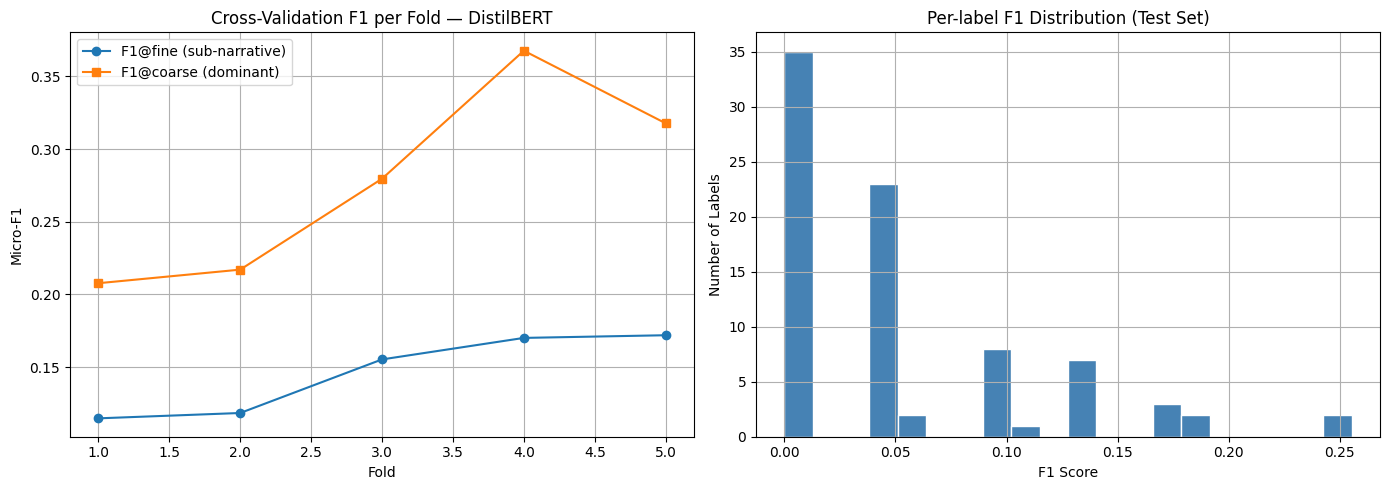

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

folds = list(range(1, len(cv_results["f1_fine"]) + 1))
axes[0].plot(folds, cv_results["f1_fine"],   marker="o", label="F1@fine (sub-narrative)")
axes[0].plot(folds, cv_results["f1_coarse"], marker="s", label="F1@coarse (dominant)")
axes[0].set_title("Cross-Validation F1 per Fold: DistilBERT")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Micro-F1")
axes[0].legend()
axes[0].grid(True)

axes[1].hist(per_label_f1, bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Per-label F1 Distribution (Test Set)")
axes[1].set_xlabel("F1 Score")
axes[1].set_ylabel("Number of Labels")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("bert_subtask2_results.png", dpi=150)
plt.show()


### Experimental Analysis & Results Discussion

The experimental results for the DistilBERT model highlight a challenging classification task characterized by high label imbalance and varying granularity.

1. **Cross-Validation Performance (Left Plot):** The model consistently achieves higher Micro-F1 scores on the coarse-grained classification task (`F1@coarse`, dominant narratives) compared to the fine-grained task (`F1@fine`, sub-narratives). Additionally, noticeable variance across the 5 folds  suggests sensitivity to the specific data splits, pointing to potential data sparsity or localized label imbalances within the training folds.

2. **Per-Label F1 Distribution (Right Plot):** The test set evaluation reveals a severe zero-shot or low-frequency label bottleneck. A massive cluster of labels yields an F1 score of $0.0$, indicating that the model completely fails to generalize to a vast majority of the individual sub-narratives. Only a small handful of labels achieve decent performance. This heavily skewed distribution confirms that overall performance is being carried by a few highly frequent, well-represented classes, while a long tail of underrepresented labels remains entirely unlearned.

## Save Predictions in Required Output Format

Format: `<article_id>\t<dominant_narratives>\t<sub_narratives>`


In [ ]:
with open(OUTPUT_FILE, "w", encoding="utf-8") as fout:
    for i, row in df_test.iterrows():
        pred_subs = [
            sub_mlb.classes_[j]
            for j in range(len(sub_mlb.classes_))
            if pred_sub_test[i, j] == 1
        ]
        pred_doms = list(dict.fromkeys(
            sub2dom[s] for s in pred_subs if sub2dom.get(s)
        ))
        if not pred_subs:
            pred_subs = ["Other"]
            pred_doms = ["Other"]
        fout.write(f"{row['article_id']}\t{';'.join(pred_doms)}\t{';'.join(pred_subs)}\n")

print(f"Predictions saved to {OUTPUT_FILE}")
with open(OUTPUT_FILE, "r", encoding="utf-8") as fin:
    for i, line in enumerate(fin):
        print(line.strip())
        if i >= 2: break


Predictions saved to /content/drive/MyDrive/NLP_Project/predictions_subtask2_EN_bert.txt
EN_UA_DEV_100012.txt	CC: Amplifying Climate Fears;CC: Climate change is beneficial;CC: Controversy about green technologies;CC: Criticism of climate movement;CC: Criticism of climate policies;CC: Criticism of institutions and authorities;CC: Downplaying climate change;CC: Green policies are geopolitical instruments;CC: Hidden plots by secret schemes of powerful groups;CC: Questioning the measurements and science;URW: Amplifying war-related fears;URW: Blaming the war on others rather than the invader;URW: Discrediting Ukraine;URW: Discrediting the West, Diplomacy;URW: Distrust towards Media;URW: Negative Consequences for the West;URW: Overpraising the West;URW: Praise of Russia;URW: Russia is the Victim;URW: Speculating war outcomes	CC: Amplifying Climate Fears: Amplifying existing fears of global warming;CC: Amplifying Climate Fears: Doomsday scenarios for humans;CC: Amplifying Climate Fears: Other

---
> ***NLP Case Study - Subtask_2 (DistilBERT) | Manuel Carlucci | Mtr: 855237 | m.carlucci69@studenti.uniba.it***


Usa tokenizeer di Bert. Capisci lunghezza media token (#medio token) e setta max_len sopra la media. Warmpu fallo fra 2 e 5%